In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# Chapter 7 — Support Vector Machines (SVM)
## Lesson 10: Scaling SVMs (Approximate Kernels, Linear SVMs, Complexity)

This lesson is about a very practical question:

> **How do we keep the “SVM idea” (large-margin classification) when the dataset becomes too large for a full kernel SVM?**

We will connect three perspectives:

1. **Optimization perspective:** kernel SVMs are quadratic programs involving an $n\times n$ kernel matrix.
2. **Systems perspective:** memory and CPU budgets force approximations; “exact” is often impossible.
3. **Modeling perspective:** linear SVMs can be extremely strong when the feature space is high-dimensional (often sparse).

We will work with **three datasets selected (randomly) from your repository**:

- `../../../Datasets/Classification/glass.csv` (multi-class, numeric)
- `../../../Datasets/Classification/stars.csv` (mixed numeric + categorical)
- `../../../Datasets/Classification/diabetes.csv` (binary, numeric)

### Learning objectives

By the end you should be able to:

1. Explain the **time and memory complexity** of kernel SVMs (Gram matrix construction + QP solving).
2. Decide when a **linear SVM** is the right baseline (especially for high-dimensional sparse features).
3. Implement scalable linear SVM training using `LinearSVC` and `SGDClassifier(loss="hinge")`.
4. Replace a kernel SVM with **approximate kernel features** using `RBFSampler` and `Nystroem`.
5. Build a production-friendly evaluation loop: **pipelines**, **cross-validation**, and **calibration** (when probabilities are needed).
6. Read accuracy/runtime tradeoffs through a simple **complexity budget** and make a justified choice.

---

### A conceptual roadmap

```mermaid
flowchart TD
    A["Data size (n) and dimension (d)"] --> B["Need nonlinear boundary?"]
    B -->|No| C["Linear SVM (primal)"]
    B -->|Yes| D["Can you afford kernel SVM? (O(n^2) memory)"]
    D -->|Yes| E["Kernel SVM (SVC)"]
    D -->|No| F["Approximate kernel features"]
    F --> G["Random Fourier Features (RBFSampler)"]
    F --> H["Nyström approximation (Nystroem)"]
    C --> I["Tune C / alpha"]
    G --> J["Tune n_components + gamma + C"]
    H --> K["Tune n_components + gamma + C"]
    I --> L["(Optional) Calibrate probabilities"]
    J --> L
    K --> L
```

We will implement each branch and discuss when it is appropriate.


## 1) Why scaling SVMs becomes hard

### 1.1 Soft-margin SVM recap (primal)

For binary labels $y_i \in \{-1,+1\}$ and feature vectors $x_i \in \mathbb{R}^d$, the soft-margin SVM solves:

$$
\min_{w,b,\xi \ge 0}\quad \frac{1}{2}\lVert w\rVert^2 + C \sum_{i=1}^n \xi_i
\quad\text{s.t.}\quad
y_i(w^\top x_i + b) \ge 1 - \xi_i.
$$

Using hinge loss $\ell_{\text{hinge}}(z) = \max(0, 1 - z)$, the equivalent unconstrained form is:

$$
\min_{w,b}\quad \frac{1}{2}\lVert w\rVert^2 + C \sum_{i=1}^n \max\left(0,\, 1 - y_i(w^\top x_i + b)\right).
$$

This form already hints at scalability: it is “regularized empirical risk minimization” and can be optimized by first-order methods.

### 1.2 Dual view (where kernels enter)

The dual introduces multipliers $\alpha_i$ and depends on dot products $x_i^\top x_j$. In a kernel SVM, those dot products are replaced by:

$$
K(x_i, x_j)=\phi(x_i)^\top \phi(x_j),
$$

without explicitly forming $\phi(\cdot)$. The optimization depends on the Gram matrix $K\in\mathbb{R}^{n\times n}$.

### 1.3 Two scaling bottlenecks

1. **Memory bottleneck (hard limit):** storing $K$ is $O(n^2)$ numbers.
2. **Optimization bottleneck:** QP solvers (including SMO variants) repeatedly access kernel values and typically grow much worse than linear with $n$.

Even if the solver is clever, the $n^2$ memory footprint is often the first thing that breaks.

### 1.4 A concrete memory budget calculation

If you store an $n\times n$ kernel matrix in float64, you need:

$$
\text{Memory} \approx 8n^2 \text{ bytes}.
$$

Examples:

- $n=10{,}000 \Rightarrow 8\times 10^8$ bytes $\approx 0.8$ GB
- $n=50{,}000 \Rightarrow 8\times 2.5\times 10^9$ bytes $\approx 20$ GB
- $n=100{,}000 \Rightarrow 8\times 10^{10}$ bytes $\approx 80$ GB

So kernel SVMs quickly exceed typical RAM sizes.

### 1.5 Prediction-time scaling is also important

Kernel SVM prediction for a new point $x$ typically looks like:

$$
f(x)=\sum_{i\in\text{SV}} \alpha_i y_i K(x_i, x) + b,
$$

where SV is the set of support vectors. That means inference cost is roughly:

$$
O(|\text{SV}|\cdot d) \quad \text{(or kernel eval cost)}.
$$

In large datasets, $|\text{SV}|$ can be large. Linear models predict in $O(d)$ (or $O(\text{nnz})$ for sparse).

**Scaling is therefore both training-time and serving-time.**

---


## 1.6 KKT conditions and the meaning of “support vectors” (why inference can be expensive)

The phrase “support vector” is not just a name; it comes directly from KKT optimality conditions.

### 1.6.1 KKT in soft-margin SVM (binary)

From the primal constraints:

$$
y_i(w^\top x_i + b) \ge 1 - \xi_i,\qquad \xi_i \ge 0
$$

introduce Lagrange multipliers:

- $\alpha_i \ge 0$ for the margin constraints
- $\mu_i \ge 0$ for $\xi_i \ge 0$

At optimum, KKT gives complementarity:

$$
\alpha_i\,[y_i(w^\top x_i + b) - 1 + \xi_i] = 0,\qquad \mu_i \xi_i = 0.
$$

It also gives the stationarity conditions (sketch):

$$
w = \sum_{i=1}^n \alpha_i y_i x_i,\qquad \sum_{i=1}^n \alpha_i y_i = 0,
$$

and bounds $0 \le \alpha_i \le C$.

### 1.6.2 Interpreting cases

There are three important regimes for each training point:

1. **Correct with margin:** $y_i(w^\top x_i+b) > 1$  
   Then typically $\alpha_i = 0$. These points do not affect the solution.

2. **On the margin:** $y_i(w^\top x_i+b) = 1$  
   Often $0 < \alpha_i < C$. These are “classic” support vectors: moving them changes the separating hyperplane.

3. **Inside margin / misclassified:** $y_i(w^\top x_i+b) < 1$  
   Then $\xi_i > 0$ and often $\alpha_i = C$. These points strongly influence the solution.

**Support vectors are the points with $\alpha_i > 0$.**

### 1.6.3 Why support vectors matter for scaling

Kernel prediction uses:

$$
f(x)=\sum_{i\in SV} \alpha_i y_i K(x_i, x) + b.
$$

So inference cost is proportional to $|SV|$. On some datasets (especially noisy or non-separable ones), a large fraction of points become support vectors, making inference expensive.

Linear models avoid this because prediction is a single dot product $w^\top x$.

### 1.6.4 Practical implication

Even if you can train a kernel SVM, you should still ask:

- How many support vectors does it use?
- Is inference time acceptable for my serving constraints?

That is why scalable workflows often prefer linear or approximate-kernel models.


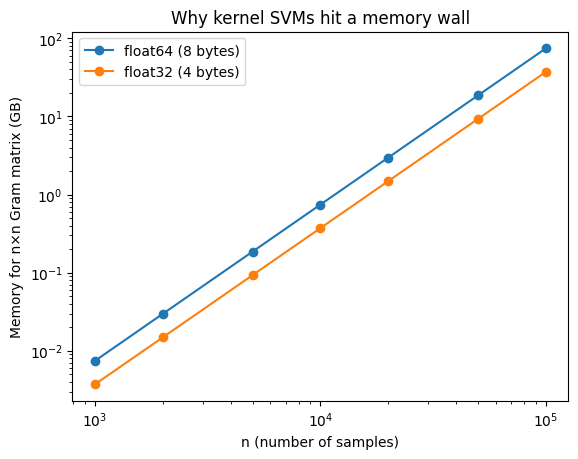

In [2]:
# Visualize the memory requirement of a full n×n Gram matrix
import numpy as np
import matplotlib.pyplot as plt

def gram_memory_gb(n, dtype_bytes=8):
    return dtype_bytes * (n**2) / (1024**3)

ns = np.array([1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000])
mem64 = [gram_memory_gb(n, 8) for n in ns]
mem32 = [gram_memory_gb(n, 4) for n in ns]

plt.figure()
plt.plot(ns, mem64, marker="o", label="float64 (8 bytes)")
plt.plot(ns, mem32, marker="o", label="float32 (4 bytes)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (number of samples)")
plt.ylabel("Memory for n×n Gram matrix (GB)")
plt.title("Why kernel SVMs hit a memory wall")
plt.legend()
plt.show()


## 2) The practical scaling toolbox

In practice, “scaling SVMs” usually means you choose among the following *families*:

### 2.1 Linear SVMs (work in the primal)

You keep the hinge-loss + $\ell_2$ regularization idea, but you train a **linear** separator in some feature space (possibly very large and sparse). Training complexity is much closer to:

$$
O(n\cdot d) \quad \text{per epoch (dense)} \qquad\text{or}\qquad O(\text{nnz}) \quad \text{(sparse)}.
$$

### 2.2 Approximate kernel features (explicit nonlinear map)

You create explicit features $\tilde{\phi}(x)\in\mathbb{R}^D$ such that:

$$
K(x,x') \approx \tilde{\phi}(x)^\top \tilde{\phi}(x').
$$

Then you train a linear model on $D$ features. The main knob is $D$:

- Larger $D$ → better approximation → slower and more memory.
- Smaller $D$ → faster → possibly less accurate.

### 2.3 “Reduce effective n” tactics

When even linear models are heavy, you can also use sampling, sketching, streaming updates, or distributed training. Those are covered in later chapters (Scalable and Online ML), but we will still show a *minimal* streaming pattern with `partial_fit` in this lesson.

---


## 2.4 How kernel SVM solvers behave (what “scales badly” really means)

When people say “kernel SVMs don’t scale,” they usually mean: **the solver needs to repeatedly access kernel values among many pairs of samples**.

### 2.4.1 The optimization object in the dual

For soft-margin SVM, the dual (binary case) is:

$$
\max_{\alpha}\quad \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(x_i,x_j)
$$

subject to constraints:

$$
0 \le \alpha_i \le C,\qquad \sum_{i=1}^n \alpha_i y_i = 0.
$$

Key observation: the quadratic term uses **all pairs** $(i,j)$. Even if the solution is sparse (many $\alpha_i=0$), the solver generally must *search* for that sparsity by iterating and checking many constraints.

### 2.4.2 SMO intuition (Sequential Minimal Optimization)

Most classic kernel SVM implementations (including libsvm) use a variant of **SMO**, which repeatedly updates a small working set of variables (often 2) while keeping others fixed.

A simplified SMO loop looks like:

1. Choose a pair $(i,j)$ that violates KKT conditions the most.
2. Solve the 2-variable subproblem analytically (depends on kernel values).
3. Update bias terms and cache partial results.
4. Repeat until convergence.

Why does this become expensive? Because step (1) needs information about many constraints, and steps (2)-(3) require frequent kernel evaluations, especially when $n$ grows.

### 2.4.3 Kernel caching and the hidden cost of “distance computations”

In practice, kernel SVM training time is often dominated by:

- computing $K(x_i, x_j)$ for many pairs
- moving those values through memory caches (CPU cache / RAM)

Even if you do not store the full Gram matrix, the solver will still evaluate many kernel entries. If data is large, the kernel cache misses become costly.

### 2.4.4 Shrinking, chunking, and active sets

Real solvers use heuristics:

- **Shrinking:** temporarily remove variables unlikely to change (based on KKT checks).
- **Chunking:** solve SVM on subsets and expand.
- **Active set selection:** focus on points near the margin.

These help, but they do not remove the fundamental $n^2$ *nature* of kernel interactions. They are best seen as “constant factor improvements,” not a change in asymptotic behavior.

### 2.4.5 Practical takeaway

Kernel SVMs are best when:

- $n$ is not too large (often a few thousand to maybe tens of thousands, depending on hardware)
- you really need a nonlinear boundary
- and inference-time cost (support vectors) is acceptable

If any of these fail, **move to linear or approximate kernels.**


In [3]:
# Core scientific stack
import numpy as np
import pandas as pd

# Modeling / preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# SVMs and scalable variants
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

# Kernel approximation
from sklearn.kernel_approximation import RBFSampler, Nystroem

# Synthetic data for scaling demos
from sklearn.datasets import make_classification

# Utilities
import time
import matplotlib.pyplot as plt
from pathlib import Path


## 3) Load datasets from the repository (relative paths)

We will read data using relative paths (relative to the notebook file location in your repo):

- `../../../Datasets/Classification/glass.csv`
- `../../../Datasets/Classification/stars.csv`
- `../../../Datasets/Classification/diabetes.csv`

The next cell defines a helper that checks file existence and loads with `pandas.read_csv`.


In [4]:
def load_csv(rel_path: str) -> pd.DataFrame:
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"Expected dataset at: {p.resolve()}\n"
            "Make sure you are running this notebook inside the repo and the relative paths match the repo structure."
        )
    return pd.read_csv(p)

paths = {
    "glass": "../../../Datasets/Classification/glass.csv",
    "stars": "../../../Datasets/Classification/stars.csv",
    "diabetes": "../../../Datasets/Classification/diabetes.csv",
}

glass_df = load_csv(paths["glass"])
stars_df = load_csv(paths["stars"])
diabetes_df = load_csv(paths["diabetes"])

display(glass_df.head())
display(stars_df.head())
display(diabetes_df.head())


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,Red Dwarf
1,3042,0.000500,0.1542,16.60,Red,M,Red Dwarf
2,2600,0.000300,0.1020,18.70,Red,M,Red Dwarf
3,2800,0.000200,0.1600,16.65,Red,M,Red Dwarf
4,1939,0.000138,0.1030,20.06,Red,M,Red Dwarf


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


## 4) Dataset 1: `glass.csv` (multi-class) — kernel SVM vs approximate kernels

### 4.1 Why this dataset is useful for this lesson

The glass dataset is a classic **multi-class** classification task with numeric features (`RI, Na, Mg, ...`) and a categorical target `Type`.

- It is small enough to run a “true” kernel SVM quickly.
- It is complex enough that nonlinear boundaries can help.
- It is a clean playground for **Nyström** and **Random Fourier Features**.

### 4.2 Models we will compare

We compare three pipelines:

1. **Kernel SVM (RBF):** `SVC(kernel="rbf")` — strong nonlinearity, not scalable.
2. **Nyström + LinearSVC:** `Nystroem` builds explicit features, then `LinearSVC` trains in the primal.
3. **RFF (RBFSampler) + LinearSVC:** an explicit randomized map for the RBF kernel.

All pipelines include `StandardScaler` and are fit inside the pipeline (no leakage).

### 4.3 About hyperparameters (what matters most)

- `C` controls the regularization / margin-violation tradeoff.
- `gamma` (for RBF) controls locality of the decision boundary.
- `n_components` controls the approximation quality in Nyström/RFF.

A practical tuning approach:
1. Pick a reasonable `gamma` range using heuristics (or grid search).
2. Pick `n_components` based on runtime budget.
3. Tune `C` last (or together with `gamma`).

---


In [5]:
# Prepare X/y for the glass dataset
glass = glass_df.copy()

# Target column name in your dataset is "Type"
y_glass = glass["Type"]
X_glass = glass.drop(columns=["Type"])

X_train, X_test, y_train, y_test = train_test_split(
    X_glass, y_glass, test_size=0.25, random_state=42, stratify=y_glass
)

numeric_features = X_glass.columns.tolist()

preprocess_numeric = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

# Define three pipelines
svc_rbf = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("clf", SVC(kernel="rbf", C=10.0, gamma="scale"))
])

nystroem_linear = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("feat", Nystroem(kernel="rbf", gamma=0.2, n_components=500, random_state=42)),
    ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
])

rff_linear = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("feat", RBFSampler(gamma=0.2, n_components=500, random_state=42)),
    ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
])

pipelines = {
    "Kernel SVC (RBF)": svc_rbf,
    "Nyström + LinearSVC": nystroem_linear,
    "RFF (RBFSampler) + LinearSVC": rff_linear
}


In [6]:
def fit_time_score(pipe, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    t1 = time.perf_counter()
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    return (t1 - t0), acc, f1, pred

results = []
preds = {}

for name, pipe in pipelines.items():
    dt, acc, f1m, pred = fit_time_score(pipe, X_train, y_train, X_test, y_test)
    results.append((name, dt, acc, f1m))
    preds[name] = pred

results_df = pd.DataFrame(results, columns=["Model", "Fit time (s)", "Accuracy", "Macro F1"])
results_df.sort_values("Fit time (s)", inplace=True)
results_df


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(


,Model,Fit time (s),Accuracy,Macro F1
0,Kernel SVC (RBF),0.036442,0.740741,0.703704
2,RFF (RBFSampler) + LinearSVC,0.110478,0.740741,0.651624
1,Nyström + LinearSVC,3.903510,0.740741,0.690212


### 4.4 Results interpretation (accuracy vs budget)

Use the table above like an engineer:

- If kernel SVC is only slightly better but much slower, that’s a strong argument to use approximate kernels.
- If approximate kernels lose too much accuracy, increase `n_components` or retune `gamma`.
- If all are similar, choose the fastest and simplest model.

A common outcome is an “elbow” behavior: as `n_components` increases, accuracy improves quickly at first, then saturates.

Next, we visualize a confusion matrix for the fastest model.


Visualizing confusion matrix for: Kernel SVC (RBF)


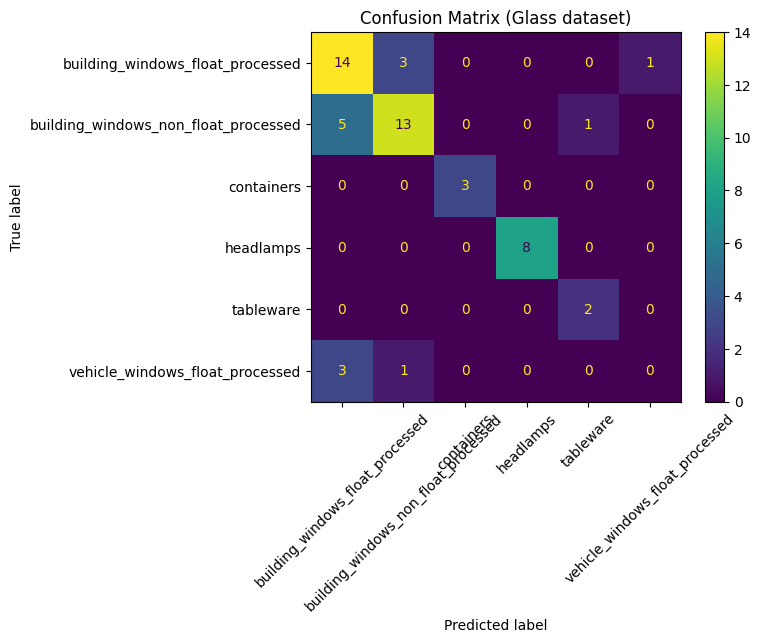

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.64      0.78      0.70        18
building_windows_non_float_processed       0.76      0.68      0.72        19
                          containers       1.00      1.00      1.00         3
                           headlamps       1.00      1.00      1.00         8
                           tableware       0.67      1.00      0.80         2
     vehicle_windows_float_processed       0.00      0.00      0.00         4

                            accuracy                           0.74        54
                           macro avg       0.68      0.74      0.70        54
                        weighted avg       0.71      0.74      0.72        54



In [7]:
# Pick a model to visualize (here: the fastest by fit time)
fastest_model = results_df.iloc[0]["Model"]
print("Visualizing confusion matrix for:", fastest_model)

best_pred = preds[fastest_model]
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, xticks_rotation=45)
plt.title("Confusion Matrix (Glass dataset)")
plt.show()

print(classification_report(y_test, best_pred))


### 4.5 Sweeping `n_components` (how approximation quality trades off with time)

We now run a small sweep over `n_components` for RFF and Nyström while keeping other hyperparameters fixed.

This gives you a concrete picture of:

- How much accuracy you gain per added feature dimension
- Where the curve saturates (“no free lunch”)

> Note: On very small datasets, timing noise can be large. For serious benchmarking, repeat runs and take mean±std.


In [8]:
n_components_grid = [50, 100, 200, 500, 1000, 2000]

def make_rff_pipe(nc):
    return Pipeline(steps=[
        ("pre", preprocess_numeric),
        ("feat", RBFSampler(gamma=0.2, n_components=nc, random_state=42)),
        ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
    ])

def make_nys_pipe(nc):
    return Pipeline(steps=[
        ("pre", preprocess_numeric),
        ("feat", Nystroem(kernel="rbf", gamma=0.2, n_components=nc, random_state=42)),
        ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
    ])

rows = []
for nc in n_components_grid:
    for label, maker in [("RFF", make_rff_pipe), ("Nyström", make_nys_pipe)]:
        pipe = maker(nc)
        dt, acc, f1m, _ = fit_time_score(pipe, X_train, y_train, X_test, y_test)
        rows.append((label, nc, dt, acc, f1m))

sweep_df = pd.DataFrame(rows, columns=["Approx", "n_components", "Fit time (s)", "Accuracy", "Macro F1"])
sweep_df.sort_values(["Approx", "n_components"], inplace=True)
sweep_df


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarni

,Approx,n_components,Fit time (s),Accuracy,Macro F1
1,Nyström,50,0.193003,0.666667,0.653822
3,Nyström,100,0.701094,0.722222,0.661165
5,Nyström,200,0.564445,0.740741,0.690212
7,Nyström,500,0.855101,0.740741,0.690212
9,Nyström,1000,0.693226,0.740741,0.690212
11,Nyström,2000,0.334283,0.740741,0.690212
0,RFF,50,0.026993,0.685185,0.701337
2,RFF,100,0.031964,0.740741,0.754024
4,RFF,200,0.046631,0.703704,0.622145
6,RFF,500,0.109434,0.740741,0.651624


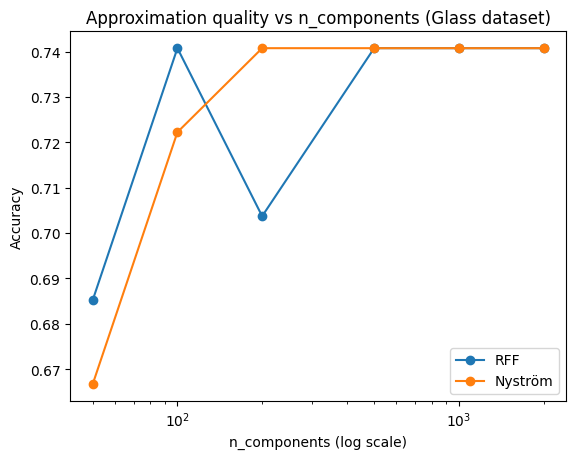

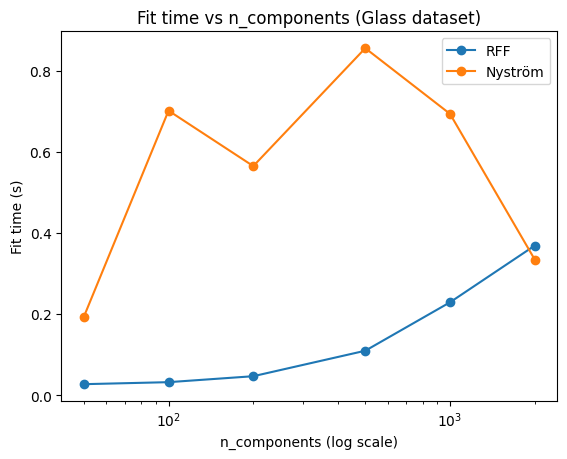

In [9]:
# Plot accuracy vs n_components
plt.figure()
for approx in ["RFF", "Nyström"]:
    sub = sweep_df[sweep_df["Approx"] == approx]
    plt.plot(sub["n_components"], sub["Accuracy"], marker="o", label=approx)
plt.xscale("log")
plt.xlabel("n_components (log scale)")
plt.ylabel("Accuracy")
plt.title("Approximation quality vs n_components (Glass dataset)")
plt.legend()
plt.show()

# Plot fit time vs n_components
plt.figure()
for approx in ["RFF", "Nyström"]:
    sub = sweep_df[sweep_df["Approx"] == approx]
    plt.plot(sub["n_components"], sub["Fit time (s)"], marker="o", label=approx)
plt.xscale("log")
plt.xlabel("n_components (log scale)")
plt.ylabel("Fit time (s)")
plt.title("Fit time vs n_components (Glass dataset)")
plt.legend()
plt.show()


### 4.6 (Optional) A small GridSearchCV for approximate kernels

Below is a small grid search for the RFF pipeline on `glass.csv`. This demonstrates the pattern you would use on larger datasets:

- keep a modest grid
- use stratified CV
- measure both accuracy and runtime (you can extend this to custom scorers)

On large datasets, you would often do this on a subset first.


In [10]:
# Small GridSearchCV example (RFF on glass dataset)
rff_pipe = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("feat", RBFSampler(random_state=42)),
    ("clf", LinearSVC(dual=False, max_iter=20000, random_state=42))
])

param_grid = {
    "feat__gamma": [0.05, 0.1, 0.2, 0.5],
    "feat__n_components": [200, 500, 1000],
    "clf__C": [0.5, 1.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=rff_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

t0 = time.perf_counter()
gs.fit(X_train, y_train)
t1 = time.perf_counter()

print("GridSearch fit time (s):", t1 - t0)
print("Best params:", gs.best_params_)
print("Best CV accuracy:", gs.best_score_)

best_model = gs.best_estimator_
pred = best_model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, pred))


GridSearch fit time (s): 13.781031900005473
Best params: {'clf__C': 1.0, 'feat__gamma': 0.05, 'feat__n_components': 1000}
Best CV accuracy: 0.69375
Test accuracy: 0.7222222222222222


### 4.7 Support vectors and inference cost (why kernel models can be slow in production)

Even if training is feasible, kernel SVM inference cost scales with the number of support vectors.

We inspect how many support vectors the trained kernel model used on the glass dataset and compare a rough inference timing to a linear model.


In [11]:
# Support vectors count (glass kernel SVC)
# Fit kernel model (if not already fit)
svc_rbf.fit(X_train, y_train)
svc_est = svc_rbf.named_steps["clf"]

print("Number of support vectors per class:", svc_est.n_support_)
print("Total number of support vectors:", int(np.sum(svc_est.n_support_)))

# Rough inference timing: kernel vs linear (use a small batch)
X_batch = X_test.iloc[:50]

t0 = time.perf_counter()
_ = svc_rbf.predict(X_batch)
t1 = time.perf_counter()

t2 = time.perf_counter()
_ = rff_linear.predict(X_batch)
t3 = time.perf_counter()

print("Kernel SVC predict time for 50 samples (s):", t1 - t0)
print("RFF+LinearSVC predict time for 50 samples (s):", t3 - t2)


Number of support vectors per class: [39 43  9 11  6 13]
Total number of support vectors: 121
Kernel SVC predict time for 50 samples (s): 0.008890199998859316
RFF+LinearSVC predict time for 50 samples (s): 0.0072979999968083575


## 5) Strategy 1 — Linear SVMs and why they scale

### 5.1 Hinge loss vs squared hinge loss

Two popular margin losses for linear SVM training are:

- Hinge loss: $\max(0, 1 - y f(x))$
- Squared hinge loss: $\max(0, 1 - y f(x))^2$

Squared hinge is smoother (differentiable almost everywhere) and often works well with certain solvers. In scikit-learn:

- `LinearSVC` uses **squared hinge** by default (`loss="squared_hinge"`).
- `SGDClassifier(loss="hinge")` uses the classic hinge.

### 5.2 Why linear is often enough

The phrase “linear model” is misleading in practice. Linear separators in a transformed feature space can represent very complex decision boundaries. Examples:

- One-hot encoded categorical interactions
- Bag-of-words / tf-idf features for text
- Polynomial features (explicit)
- Random features for kernel approximation

In all these cases, training is “linear” in the final feature space, but the decision boundary in raw input space can be highly nonlinear.

### 5.3 Solver intuition

- `LinearSVC` (liblinear): coordinate descent / specialized optimization; often strong default for medium-sized data.
- `SGDClassifier`: truly scalable; works for millions of samples; supports streaming updates and is easy to distribute.

In scaling work, you typically start with linear baselines, and only pay for nonlinearity when necessary.

---


## 5.4 Linear SVM optimization mechanics (subgradients, Pegasos-style updates)

To understand why linear SVMs scale, it helps to see a typical update rule.

Consider the regularized hinge objective (no bias for simplicity):

$$
\min_w \quad \frac{\lambda}{2}\lVert w\rVert^2 + \frac{1}{n}\sum_{i=1}^n \max(0, 1 - y_i w^\top x_i).
$$

A subgradient of the hinge loss for a single example is:

- If $y_i w^\top x_i \ge 1$: subgradient is $0$ (already correctly classified with margin).
- If $y_i w^\top x_i < 1$: subgradient is $-y_i x_i$ (push $w$ to increase margin).

So a stochastic subgradient step (one sample) looks like:

$$
w \leftarrow (1-\eta \lambda)w + \eta \, y_i x_i \, \mathbf{1}[y_i w^\top x_i < 1],
$$

where $\eta$ is a learning rate.

### Pegasos (intuition)

Pegasos is a classic method with step size $\eta_t=1/(\lambda t)$ and sometimes a projection step to keep $\lVert w\rVert$ bounded. The key property is that each iteration is **cheap**:

- you compute $w^\top x_i$ (cost $O(d)$ or $O(\text{nnz})$)
- you update $w$

No kernel matrix. No pairwise interactions.

### Why this yields “near-linear scaling”

If you do $T$ iterations (or a few epochs), total cost is roughly:

$$
O(T\cdot d),
$$

and for many problems $T$ grows slowly compared to $n^2$. This is why linear SVMs can handle huge datasets.

### Connection to `SGDClassifier`

`SGDClassifier(loss="hinge")` is essentially this family, with practical enhancements:

- learning rate schedules
- averaging
- regularization options
- early stopping via `tol`

This is the backbone of scalable linear SVM training.


## 6) Dataset 2: `stars.csv` — linear SVM on mixed (numeric + categorical) data

The stars dataset includes:

- Numeric: `Temperature, L, R, A_M`
- Categorical: `Color, Spectral_Class`
- Target: `Type`

### 6.1 Preprocessing pipeline

We build a `ColumnTransformer`:

- `StandardScaler` on numeric columns
- `OneHotEncoder(handle_unknown="ignore")` on categorical columns

Then compare:

- `LinearSVC`
- `SGDClassifier(loss="hinge")`

We also show a calibrated version (optional) to produce probabilities.

---


In [12]:
stars = stars_df.copy()

# Target column is "Type"
y_stars = stars["Type"]
X_stars = stars.drop(columns=["Type"])

# Infer numeric vs categorical columns
numeric_cols = X_stars.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_stars.columns if c not in numeric_cols]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stars, y_stars, test_size=0.25, random_state=42, stratify=y_stars
)

# OneHotEncoder parameter name differs across sklearn versions; handle both.
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess_mixed = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols),
    ],
    remainder="drop"
)

lin_svc = Pipeline(steps=[
    ("pre", preprocess_mixed),
    ("clf", LinearSVC(C=1.0, dual=True, max_iter=20000, random_state=42))
])

sgd_svm = Pipeline(steps=[
    ("pre", preprocess_mixed),
    ("clf", SGDClassifier(loss="hinge", alpha=1e-4, max_iter=4000, tol=1e-3, random_state=42))
])

models = {"LinearSVC": lin_svc, "SGDClassifier (hinge)": sgd_svm}

stars_results = []
stars_preds = {}

for name, pipe in models.items():
    t0 = time.perf_counter()
    pipe.fit(X_train_s, y_train_s)
    t1 = time.perf_counter()
    pred = pipe.predict(X_test_s)
    dt = t1 - t0
    acc = accuracy_score(y_test_s, pred)
    f1m = f1_score(y_test_s, pred, average="macro")
    stars_results.append((name, dt, acc, f1m))
    stars_preds[name] = pred

pd.DataFrame(stars_results, columns=["Model", "Fit time (s)", "Accuracy", "Macro F1"]).sort_values("Fit time (s)")


,Model,Fit time (s),Accuracy,Macro F1
0,LinearSVC,0.058799,1.000000,1.000000
1,SGDClassifier (hinge),0.085425,0.983333,0.983292


### 6.2 Interpretation (why this is “scaling-friendly”)

After one-hot encoding, your feature space can become very high-dimensional but sparse.

Linear models scale with the number of nonzero entries, so they remain feasible even when the “raw dimension” is large.

Next: confusion matrix for the linear SVM model.


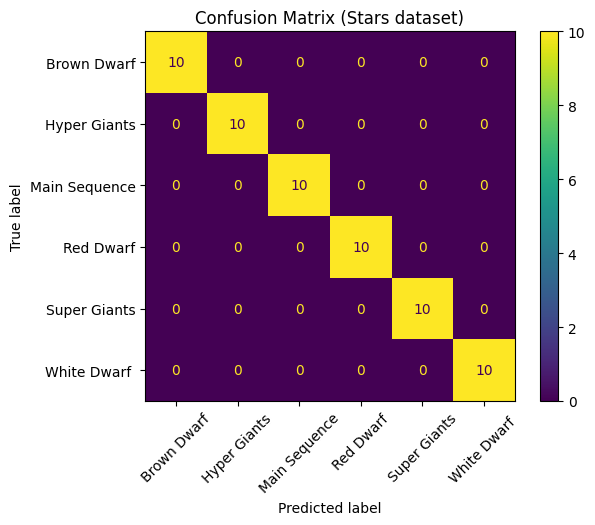

               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00        10
 Hyper Giants       1.00      1.00      1.00        10
Main Sequence       1.00      1.00      1.00        10
    Red Dwarf       1.00      1.00      1.00        10
 Super Giants       1.00      1.00      1.00        10
 White Dwarf        1.00      1.00      1.00        10

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60



In [13]:
ConfusionMatrixDisplay.from_predictions(y_test_s, stars_preds["LinearSVC"], xticks_rotation=45)
plt.title("Confusion Matrix (Stars dataset)")
plt.show()

print(classification_report(y_test_s, stars_preds["LinearSVC"]))


### 6.3 Optional: probability estimates at scale (calibration)

SVM margins are not probabilities. If your application needs calibrated probabilities (e.g., decision thresholds, expected utility, risk), you usually do **post-hoc calibration**.

A common scalable approach:

- Train a fast margin model (LinearSVC or SGDClassifier).
- Calibrate it using `CalibratedClassifierCV` on held-out folds.

This is typically cheaper than training a kernel SVM with `probability=True`.

We show a small example with `LinearSVC` below.


In [14]:
calibrated = Pipeline(steps=[
    ("pre", preprocess_mixed),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, dual=True, max_iter=20000, random_state=42),
        method="sigmoid",
        cv=3
    ))
])

t0 = time.perf_counter()
calibrated.fit(X_train_s, y_train_s)
t1 = time.perf_counter()

proba = calibrated.predict_proba(X_test_s)
pred = calibrated.predict(X_test_s)

print("Calibration fit time (s):", t1 - t0)
print("Accuracy:", accuracy_score(y_test_s, pred))
print("First 5 probability rows:")
proba[:5]


Calibration fit time (s): 0.13645459999679588
Accuracy: 0.9833333333333333
First 5 probability rows:


array([[1.46960768e-02, 2.14460715e-02, 1.30471182e-01, 4.08744530e-02,
        2.78400124e-03, 7.89728215e-01],
       [8.16052959e-01, 2.03582453e-02, 2.40475462e-02, 7.27108333e-02,
        6.18277932e-02, 5.00262320e-03],
       [5.00559958e-03, 2.20407318e-02, 3.42776251e-01, 6.37591551e-05,
        6.10120589e-01, 1.99930691e-02],
       [2.97999194e-01, 1.69246428e-02, 4.46670964e-03, 6.31986844e-01,
        1.76186337e-02, 3.10039754e-02],
       [1.30603347e-01, 1.45334049e-02, 2.14376421e-03, 7.69276898e-01,
        7.18666745e-03, 7.62559185e-02]])

## 7) Strategy 2 — Approximate kernels (deep dive)

Kernel methods are attractive because they create nonlinear boundaries, but full kernel SVMs can be too expensive. Approximate methods replace the implicit feature space with an explicit finite-dimensional map.

We focus on two workhorses: Random Fourier Features and Nyström.

### 7.1 Random Fourier Features (RFF) for shift-invariant kernels

For shift-invariant kernels $K(x,x')=k(x-x')$, Bochner's theorem says:

$$
k(\delta) = \int_{\mathbb{R}^d} e^{i\omega^\top \delta} p(\omega)\, d\omega,
$$

where $p(\omega)\ge 0$ is a density. The key trick is Monte Carlo integration:

1. Sample $\omega_1,\dots,\omega_D\sim p(\omega)$
2. Use a real-valued feature map:
   $$
   \tilde{\phi}(x)=\sqrt{\frac{2}{D}}[\cos(\omega_1^\top x+b_1),\dots,\cos(\omega_D^\top x+b_D)]
   $$

Then:

$$
\tilde{\phi}(x)^\top \tilde{\phi}(x') \approx K(x,x')
$$

with approximation error shrinking as $O(1/\sqrt{D})$ (variance of Monte Carlo).

**Important practical point:** you still need to scale your features properly before applying RFF, because $\omega^\top x$ is sensitive to feature magnitudes.

### 7.2 Nyström approximation

Nyström chooses $m$ landmark points and approximates $K$ by a low-rank factorization:

$$
K \approx C W^{\dagger} C^\top,
$$

where $C=K(X,\text{landmarks})$ and $W=K(\text{landmarks},\text{landmarks})$.

Nyström can be interpreted as building $m$-dimensional explicit features. It is often strong when the kernel matrix is approximately low rank.

### 7.3 When to prefer which?

- **RFF:** simple, data-independent, strong for RBF-like kernels; quality controlled by $D$.
- **Nyström:** data-dependent; can be better when there is low-rank structure and landmarks represent geometry well.

---

### A second roadmap (approximate kernel pipeline)

```mermaid
flowchart TD
    A["Raw features X"] --> B["Scale/encode in Pipeline"]
    B --> C["Approx feature map (RFF or Nyström)"]
    C --> D["Linear model (LinearSVC / SGD)"]
    D --> E["Validation + tuning"]
    E --> F["(Optional) calibration"]
```

---


## 7.4 Deriving Random Fourier Features for the RBF kernel (more math)

This section gives a more explicit derivation for the RBF case. You do **not** need to memorize it, but understanding the structure helps when tuning `gamma` and `n_components`.

### 7.4.1 Start from a shift-invariant kernel

A kernel is shift-invariant if $K(x,x') = k(x-x')$. The RBF kernel is:

$$
K(x,x') = \exp(-\gamma \lVert x-x'\rVert^2).
$$

Let $\delta = x-x'$. Then $k(\delta) = \exp(-\gamma \lVert \delta\rVert^2)$.

### 7.4.2 Fourier transform of a Gaussian is a Gaussian

A central fact: the Fourier transform of a Gaussian is also Gaussian. In $d$ dimensions, one can show (up to constants):

$$
\int_{\mathbb{R}^d} \exp(-\gamma \lVert \delta\rVert^2) \, e^{-i\omega^\top \delta} \, d\delta
\propto \exp\left(-\frac{\lVert\omega\rVert^2}{4\gamma}\right).
$$

That means the spectral density $p(\omega)$ for the RBF kernel is a Gaussian:

$$
\omega \sim \mathcal{N}(0, 2\gamma I).
$$

(Exact constants depend on the Fourier convention; the important part is the Gaussian form and scaling with $\gamma$.)

### 7.4.3 Turning the expectation into explicit features

Using Euler's formula and a random phase trick, we can write:

$$
K(x,x') = \mathbb{E}_{\omega,b}\left[\sqrt{2}\cos(\omega^\top x + b)\;\sqrt{2}\cos(\omega^\top x' + b)\right],
$$

where $b\sim \text{Unif}[0,2\pi]$ and $\omega\sim p(\omega)$.

Approximate the expectation by averaging $D$ samples:

$$
\tilde{\phi}(x)=\sqrt{\frac{2}{D}}\,[\cos(\omega_1^\top x + b_1),\dots,\cos(\omega_D^\top x + b_D)].
$$

Then:

$$
\tilde{\phi}(x)^\top \tilde{\phi}(x') \approx K(x,x').
$$

### 7.4.4 Why scaling your inputs matters

Note that features are functions of $\omega^\top x$. If one coordinate of $x$ has huge magnitude relative to others, it dominates the dot product, which effectively changes the kernel length scale in a distorted way. That is why we scale numeric features before RFF/Nyström.

### 7.4.5 Interpreting `gamma` as a length scale

For RBF, a common parameterization is:

$$
K(x,x') = \exp\left(-\frac{\lVert x-x'\rVert^2}{2\sigma^2}\right).
$$

Comparing with $\exp(-\gamma\lVert x-x'\rVert^2)$ gives:

$$
\gamma = \frac{1}{2\sigma^2}.
$$

So large $\gamma$ means small $\sigma$ → very local kernel → potentially overfitting if too local.

---


## 7.5 Approximation error and choosing `n_components` (thinking in “variance”)

Random Fourier Features and many randomized approximations behave like Monte Carlo estimators: you approximate an expectation with a finite average.

### 7.5.1 A simple variance story

Let $Z$ be a random variable whose expectation equals the kernel value:

$$
K(x,x') = \mathbb{E}[Z].
$$

You estimate it with $D$ i.i.d. samples:

$$
\hat{K}_D(x,x') = \frac{1}{D}\sum_{j=1}^D Z_j.
$$

Then:

$$
\mathrm{Var}(\hat{K}_D) = \frac{1}{D}\mathrm{Var}(Z).
$$

So the standard deviation shrinks as $1/\sqrt{D}$. This does not magically guarantee classification accuracy, but it explains why you often see an elbow: early increases in $D$ reduce approximation noise quickly; later increases do little.

### 7.5.2 Bias vs variance tradeoff in Nyström

Nyström is not purely Monte Carlo in the same way. It is more like a low-rank approximation:

- if the true kernel matrix is close to rank-$m$, Nyström can be extremely accurate for modest $m$
- if not, it may need larger $m$

Landmark selection matters. Random landmarks are simple; smarter methods (k-means centers, leverage scores) can improve quality at extra cost.

### 7.5.3 Practical heuristics you can actually use

1. **Start with a budget:** choose a maximum `n_components` you can afford.
2. **Tune `gamma` roughly:** use a small grid; `gamma="scale"` can be a baseline.
3. **Increase `n_components` until saturation:** plot accuracy vs `n_components`.
4. **If accuracy is unstable:** increase `n_components` or average results across multiple random seeds.

### 7.5.4 What about extremely large D?

When $D$ becomes very large (e.g., 50k or 100k), you are effectively moving toward a “full” feature representation. At that point:

- memory for $n\times D$ may dominate
- linear solvers may slow down
- you might be better served by other nonlinear models (trees, GBDT) depending on the problem

So `n_components` is a knob, not a free lunch.


## 8) Dataset 3: `diabetes.csv` — scaling behavior with sample size

We will:

1. Train a kernel SVM (RBF) and a scalable alternative (RFF + LinearSVC).
2. Increase the effective dataset size via bootstrapping to observe how fit time grows with $n$.
3. Compare a true streaming-style linear model using `SGDClassifier.partial_fit`.

---


In [15]:
diab = diabetes_df.copy()

y_diab = diab["classification"]
X_diab = diab.drop(columns=["classification"])

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diab, y_diab, test_size=0.25, random_state=42, stratify=y_diab
)

num_cols_d = X_diab.columns.tolist()

preprocess_d = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols_d)],
    remainder="drop"
)

svc_rbf_d = Pipeline(steps=[
    ("pre", preprocess_d),
    ("clf", SVC(kernel="rbf", C=5.0, gamma="scale"))
])

rff_lin_d = Pipeline(steps=[
    ("pre", preprocess_d),
    ("feat", RBFSampler(gamma=0.5, n_components=800, random_state=42)),
    ("clf", LinearSVC(C=5.0, dual=False, max_iter=30000, random_state=42))
])

# Baseline evaluation on the original split
base_rows = []
for name, pipe in {"Kernel SVC (RBF)": svc_rbf_d, "RFF + LinearSVC": rff_lin_d}.items():
    t0 = time.perf_counter()
    pipe.fit(X_train_d, y_train_d)
    t1 = time.perf_counter()
    pred = pipe.predict(X_test_d)
    base_rows.append((name, t1 - t0, accuracy_score(y_test_d, pred), f1_score(y_test_d, pred, average="macro")))

pd.DataFrame(base_rows, columns=["Model", "Fit time (s)", "Accuracy", "Macro F1"])


,Model,Fit time (s),Accuracy,Macro F1
0,Kernel SVC (RBF),0.037358,0.755208,0.727725
1,RFF + LinearSVC,0.174941,0.703125,0.659097


In [16]:
# Timing experiment: grow training set size by resampling with replacement
rng = np.random.default_rng(42)

def bootstrap_rows(X, y, n_rows):
    idx = rng.integers(0, len(X), size=n_rows)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

sizes = [len(X_train_d), 2*len(X_train_d), 4*len(X_train_d), 8*len(X_train_d)]
timings = {"Kernel SVC (RBF)": [], "RFF + LinearSVC": []}

for n_rows in sizes:
    Xb, yb = bootstrap_rows(X_train_d, y_train_d, n_rows)
    
    # Kernel SVC
    t0 = time.perf_counter()
    svc_rbf_d.fit(Xb, yb)
    t1 = time.perf_counter()
    timings["Kernel SVC (RBF)"].append(t1 - t0)
    
    # RFF + LinearSVC
    t0 = time.perf_counter()
    rff_lin_d.fit(Xb, yb)
    t1 = time.perf_counter()
    timings["RFF + LinearSVC"].append(t1 - t0)

timings_df = pd.DataFrame({
    "n_train": sizes,
    "Kernel SVC (RBF) time (s)": timings["Kernel SVC (RBF)"],
    "RFF + LinearSVC time (s)": timings["RFF + LinearSVC"],
})
timings_df


,n_train,Kernel SVC (RBF) time (s),RFF + LinearSVC time (s)
0,576,0.048413,0.204313
1,1152,0.080287,0.536540
2,2304,0.253379,0.984170
3,4608,1.088641,6.206531


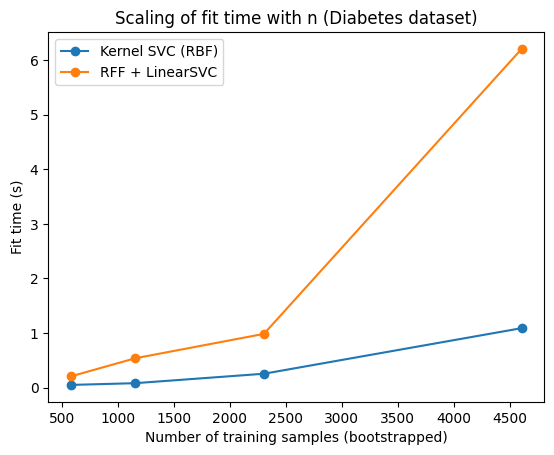

In [17]:
plt.figure()
plt.plot(timings_df["n_train"], timings_df["Kernel SVC (RBF) time (s)"], marker="o", label="Kernel SVC (RBF)")
plt.plot(timings_df["n_train"], timings_df["RFF + LinearSVC time (s)"], marker="o", label="RFF + LinearSVC")
plt.xlabel("Number of training samples (bootstrapped)")
plt.ylabel("Fit time (s)")
plt.title("Scaling of fit time with n (Diabetes dataset)")
plt.legend()
plt.show()


### 8.1 Streaming-style training with `partial_fit` (linear SVM via SGD)

When data arrives in batches (or is too large to fit in memory), you can train a linear SVM using SGD incrementally.

We demonstrate a minimal pattern:

1. Fit preprocessing (scaler) on a first batch (or use `StandardScaler` with partial methods if available).
2. Call `partial_fit` repeatedly on mini-batches.

Below we implement this with a simple manual scaling strategy: we fit a scaler on the full training set (for simplicity in a tutorial), then stream batches through `partial_fit`.

In production, you would fit scaling on a representative sample or use running statistics.


In [18]:
from sklearn.preprocessing import StandardScaler

# Prepare scaled numeric arrays for streaming
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_d.values)
X_test_scaled = scaler.transform(X_test_d.values)

# SGDClassifier supports partial_fit
classes = np.unique(y_train_d)

sgd_stream = SGDClassifier(loss="hinge", alpha=1e-4, random_state=42)

batch_size = 64
n_epochs = 10

t0 = time.perf_counter()
for epoch in range(n_epochs):
    # shuffle indices
    idx = rng.permutation(len(X_train_scaled))
    for start in range(0, len(idx), batch_size):
        batch_idx = idx[start:start+batch_size]
        Xb = X_train_scaled[batch_idx]
        yb = y_train_d.iloc[batch_idx].values
        if epoch == 0 and start == 0:
            sgd_stream.partial_fit(Xb, yb, classes=classes)
        else:
            sgd_stream.partial_fit(Xb, yb)
t1 = time.perf_counter()

pred = sgd_stream.predict(X_test_scaled)
print("Streaming SGD fit time (s):", t1 - t0)
print("Accuracy:", accuracy_score(y_test_d, pred))


Streaming SGD fit time (s): 0.3234710999968229
Accuracy: 0.7239583333333334


### 8.2 What you should observe

- Kernel SVC tends to grow **superlinearly** with $n$.
- RFF + LinearSVC grows closer to **linear** for fixed `n_components`.
- Streaming SGD can be extremely fast and memory-friendly, and becomes the default choice when $n$ is truly massive.

The tradeoff is tuning and stability: SGD models may need more care (learning rate schedule, regularization, number of epochs).

---


## 9) A synthetic scaling demo (high-dimensional linear separability)

Real datasets are not always large enough to clearly expose scaling differences. To build intuition, we generate synthetic classification problems with controlled size and dimension.

We will compare:

- `SVC(kernel="rbf")` on a modest size (to avoid very long runtime)
- `LinearSVC`
- `SGDClassifier(loss="hinge")`

The point is not best accuracy; it is **how runtime behaves as we change n and d**.


In [19]:
def benchmark_models(n_samples, n_features, random_state=42):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=max(2, n_features//10),
        n_redundant=0,
        n_classes=2,
        random_state=random_state
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state, stratify=y
    )
    
    models = {
        "Kernel SVC (RBF)": Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))]),
        "LinearSVC": Pipeline([("sc", StandardScaler()), ("clf", LinearSVC(C=1.0, dual=False, max_iter=20000, random_state=random_state))]),
        "SGD (hinge)": Pipeline([("sc", StandardScaler()), ("clf", SGDClassifier(loss="hinge", alpha=1e-4, max_iter=2000, tol=1e-3, random_state=random_state))])
    }
    
    rows = []
    for name, m in models.items():
        t0 = time.perf_counter()
        m.fit(X_train, y_train)
        t1 = time.perf_counter()
        pred = m.predict(X_test)
        rows.append((name, t1-t0, accuracy_score(y_test, pred)))
    return pd.DataFrame(rows, columns=["Model", "Fit time (s)", "Accuracy"])

benchmarks = []
for n in [1000, 2000, 5000]:
    dfb = benchmark_models(n_samples=n, n_features=200)
    dfb["n_samples"] = n
    dfb["n_features"] = 200
    benchmarks.append(dfb)

bench_df = pd.concat(benchmarks, ignore_index=True)
bench_df


,Model,Fit time (s),Accuracy,n_samples,n_features
0,Kernel SVC (RBF),0.264357,0.8120,1000,200
1,LinearSVC,0.112813,0.8040,1000,200
2,SGD (hinge),0.094936,0.8000,1000,200
3,Kernel SVC (RBF),1.320896,0.7780,2000,200
4,LinearSVC,0.090533,0.7820,2000,200
5,SGD (hinge),0.148289,0.7540,2000,200
6,Kernel SVC (RBF),4.628563,0.8360,5000,200
7,LinearSVC,0.146447,0.7960,5000,200
8,SGD (hinge),0.428806,0.7472,5000,200


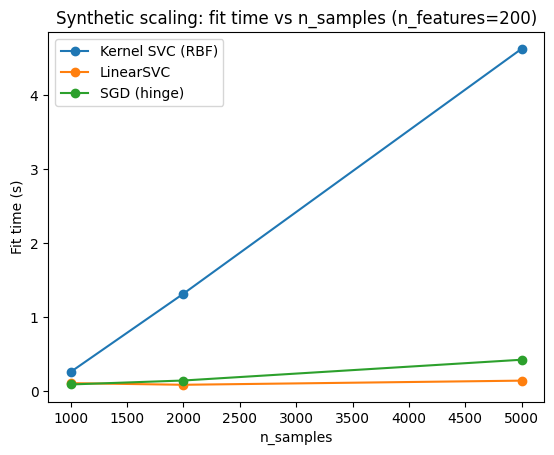

In [20]:
# Plot fit time vs n_samples for each model
plt.figure()
for model in bench_df["Model"].unique():
    sub = bench_df[bench_df["Model"] == model].sort_values("n_samples")
    plt.plot(sub["n_samples"], sub["Fit time (s)"], marker="o", label=model)
plt.xlabel("n_samples")
plt.ylabel("Fit time (s)")
plt.title("Synthetic scaling: fit time vs n_samples (n_features=200)")
plt.legend()
plt.show()


## 10) Engineering tactics for scalable SVM workflows (checklist + gotchas)

### 10.1 Put everything in a Pipeline

Always use a `Pipeline` so that:

- scaling/encoding happens inside CV folds (no leakage)
- hyperparameter searches are correct by construction
- training and inference steps are packaged together (deployable)

### 10.2 Choosing between linear solvers in practice

- If data fits in memory and you want a strong default: `LinearSVC`.
- If data is huge / streaming / you want online updates: `SGDClassifier(loss="hinge")`.
- If you need nonlinearity but kernel SVM is too expensive: `RBFSampler` or `Nystroem` + linear model.

### 10.3 Serving-time matters

- Kernel SVM inference scales with number of support vectors.
- Linear models are fast and predictable at serving time.

If you have an online system (API calls), inference cost often dominates total cost.

### 10.4 Calibration is a separate step

Do not assume margins are probabilities. If you need probabilities:

- calibrate a fast margin model
- or accept the overhead of `probability=True` in `SVC` (often expensive)

### 10.5 Common failure modes when scaling

1. **Not scaling features** → RBF behaves poorly (gamma becomes meaningless).
2. **Data leakage** by scaling on the full dataset before split.
3. **Overly large `n_components`** without checking diminishing returns.
4. **Benchmark noise**: measure multiple runs; avoid single-run timing conclusions.
5. **Imbalanced classes**: use appropriate metrics (`macro F1`, class weights) and stratification.

---


## 11) A theoretical lens: why approximation often works (more detail)

This section is optional but useful if you want a deeper mental model.

### 11.1 Large-margin principle and capacity control

SVM training balances two forces:

1. Minimizing empirical hinge loss (fit training labels).
2. Minimizing model norm (capacity control).

In linear space, this is $\lVert w\rVert^2$.
In RKHS, it is $\lVert f\rVert_{\mathcal{H}}^2$.

Margin-based bounds (conceptual statement) imply that if you maintain similar geometry in feature space, you can maintain similar generalization behavior.

### 11.2 RFF approximation as Monte Carlo integration

For shift-invariant kernels, the kernel is an expectation:

$$
K(x,x') = \mathbb{E}_{\omega\sim p(\omega)}\left[\cos(\omega^\top x + b)\cos(\omega^\top x' + b)\right] \times 2
$$

(ignoring constants for intuition).

Replacing the expectation with a sample average over $D$ draws yields an estimator with variance proportional to $1/D$. That is where the $O(1/\sqrt{D})$ convergence rate comes from.

### 11.3 Stability under kernel perturbations (sketch)

Assume you have an approximation such that for all pairs in the dataset:

$$
|K(x,x') - \tilde{K}(x,x')| \le \varepsilon.
$$

Then the Gram matrices differ by a matrix with bounded entries. With regularization, the optimization problem is strongly convex in the primal representation, which implies *solution stability* to perturbations. In simpler terms:

- small kernel approximation error → small change in the learned function
- until statistical noise dominates

This matches the empirical tuning story: you increase `n_components` until you hit diminishing returns.

---


## 11.4 A “complexity budgeting worksheet” (how to decide systematically)

When you build a real ML system, you rarely ask “what is the best model?” in abstract. You ask:

> **What is the best model that fits my latency + memory + training budget?**

Here is a simple budgeting worksheet you can apply.

### Step 1: Define constraints

- Training budget: e.g., 10 minutes on a single CPU
- Memory budget: e.g., 2 GB for features during training
- Inference budget: e.g., 5 ms per request
- Accuracy target: e.g., macro F1 ≥ 0.80

### Step 2: Map model families to cost

| Model family | Training memory | Training time growth | Inference time |
|---|---:|---:|---:|
| Kernel SVC (RBF) | $O(n^2)$ | steep (often superlinear) | $O(|SV|\cdot d)$ |
| LinearSVC | $O(nd)$ or sparse nnz | ~linear per epoch | $O(d)$ |
| SGD (hinge) | $O(d)$ to $O(nnz)$ | ~linear per epoch, streaming | $O(d)$ |
| RFF/Nyström + linear | $O(nD)$ | ~linear in $nD$ | $O(D)$ |

### Step 3: Choose the simplest family that can meet the target

1. Start with linear baseline (fast, stable).
2. If accuracy is too low, add nonlinearity via approximate features.
3. Only go full kernel if $n$ is small enough and you can afford inference with support vectors.

### Step 4: Tune within the family

- For linear: tune `C` (or `alpha` for SGD), class weights, and number of epochs.
- For RFF/Nyström: tune `gamma` and `n_components`, then `C`.

This worksheet is not “theory,” it is a practical decision procedure.


## 12) Exercises (recommended)

1. **Tune `n_components`:** On `glass.csv`, run a grid over `n_components ∈ {50, 100, 200, 500, 1000, 2000}` and plot accuracy vs time for RFF and Nyström.
2. **Tune `gamma`:** For RFF and Nyström, compare `gamma ∈ {0.05, 0.1, 0.2, 0.5, 1.0}`.
3. **Squared hinge vs hinge:** On `diabetes.csv`, compare `LinearSVC(loss="squared_hinge")` vs `SGDClassifier(loss="hinge")` and explain differences.
4. **Calibration impact:** Calibrate a linear model on `stars.csv` and inspect probability histograms (optional).
5. **Serving-time analysis:** Count number of support vectors in the kernel SVC model (`svc.support_.shape[0]`) and estimate inference cost relative to linear models.

---


## FAQ: common questions when scaling SVMs

### Q1) Should I use `SVC(kernel="linear")` or `LinearSVC`?

If you want a linear model, prefer `LinearSVC` (liblinear) or `SGDClassifier` for large scale. `SVC(kernel="linear")` still uses the libsvm machinery and can be slower / more memory-heavy for large datasets.

### Q2) What is the relationship between `C` and `alpha`?

- `C` is a penalty weight in the classic SVM formulation.
- `alpha` in SGD-style APIs is typically the coefficient of $\ell_2$ regularization.

Roughly, larger `C` means less regularization (more fit), while larger `alpha` means more regularization. The exact mapping depends on scaling by $n$ and the loss convention, so treat it as “inverse regularization strength.”

### Q3) My RBF kernel performs badly—what is wrong?

Common causes:

- features not scaled
- `gamma` too large (overly local) or too small (too smooth)
- class imbalance (consider `class_weight="balanced"` and appropriate metrics)

### Q4) When do approximate kernels *not* help?

- if the problem is essentially linear (approximation adds unnecessary noise/cost)
- if you need very complex nonlinearity and $D$ required is too large for your budget
- if feature scaling is unreliable or data distribution shifts heavily

### Q5) What is the “most scalable SVM” choice?

For truly massive datasets, the standard answer is:

- linear margin model trained with SGD (hinge loss) on well-engineered features

This is the core idea behind many industrial-scale classifiers (especially for sparse features).


## References and further reading

- C. Cortes and V. Vapnik, “Support-Vector Networks,” *Machine Learning*, 1995.
- N. Cristianini and J. Shawe-Taylor, *An Introduction to Support Vector Machines*, Cambridge University Press, 2000.
- B. Schölkopf and A. Smola, *Learning with Kernels*, MIT Press, 2002.
- A. Rahimi and B. Recht, “Random Features for Large-Scale Kernel Machines,” NeurIPS 2007.
- P. Drineas and M. Mahoney, “On the Nyström Method for Approximating a Gram Matrix for Improved Kernel-Based Learning,” JMLR 2005.
- scikit-learn documentation: `SVC`, `LinearSVC`, `SGDClassifier`, `RBFSampler`, `Nystroem`, `CalibratedClassifierCV`.

---

### Summary (one paragraph)

Kernel SVMs are powerful but limited by $O(n^2)$ memory and steep runtime growth. Scaling SVMs in practice means switching to **linear SVM training in the primal**, or using **approximate kernel feature maps** (RFF/Nyström) so you can still train a linear model. The main engineering skill is budgeting: decide how much nonlinearity you can afford, measure accuracy vs runtime, and pick the simplest model that meets requirements.
